In [120]:
import numpy as np, torch

# Neuromancer imports: modeling, loss, logging, system dynamics
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.dynamics import ode, integrators
from neuromancer.plot import pltCL, pltPhase

# SparseDPC-specific modules: libraries, data, training, utils
from SparseDPC.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.sindy.fx_library import fx_policy_library
from results.utils import *
# Set random seed for reproducibility
torch.manual_seed(0)

# Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [121]:
# ground truth system model
gt_model = psl.nonautonomous.VanDerPolControl()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = -5.
umax = 5.
xmin = -5.
xmax = 5.


In [122]:
# Create one fx model per state dimension
fx_models = [fx_library(i, nx=nx, nu=nu, seed=0, device=device,
                           max_degree=4, add_sqrt=False, add_u_prod=True) for i in range(nx)]

# Print model structures
for fx in fx_models:
    print(fx)


dx0/dt = -0.000*x0 + 0.027*x1 + -0.041*x0^2 + -0.037*x0*x1 + -0.019*x1^2 + 0.013*x0^3 + -0.001*x0^2*x1 + 0.040*x0*x1^2 + -0.004*x1^3 + 0.013*x0^4 + -0.015*x0^3*x1 + -0.010*x0^2*x1^2 + -0.048*x0*x1^3 + -0.033*x1^4 + -0.021*u_0 + 0.002*x0*u_0 + 0.020*x1*u_0

dx1/dt = -0.000*x1 + 0.027*x0 + -0.041*x0^2 + -0.037*x0*x1 + -0.019*x1^2 + 0.013*x0^3 + -0.001*x0^2*x1 + 0.040*x0*x1^2 + -0.004*x1^3 + 0.013*x0^4 + -0.015*x0^3*x1 + -0.010*x0^2*x1^2 + -0.048*x0*x1^3 + -0.033*x1^4 + -0.021*u_0 + 0.002*x0*u_0 + 0.020*x1*u_0



In [123]:
import os, glob, torch

run_id = 1
models_dir = f"results/tests/dynamics/run_{run_id}/saved_models"   # change root here

for i, model in enumerate(fx_models):
    pattern = os.path.join(models_dir, f"trained_dynamics_x{i}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No checkpoint for x{i} in {models_dir}")

    ckpt = max(matches, key=os.path.getmtime)
    state_dict = torch.load(ckpt, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"Loaded x{i} from {os.path.basename(ckpt)}")


Loaded x0 from trained_dynamics_x0_20250810_153554.pth
Loaded x1 from trained_dynamics_x1_20250810_153554.pth


In [124]:
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations

run_id = 3
### SPARSE DICTIONARY (SD) MODELS ###
SD_SINDy_policies = [fx_policy_library(nx=nx, nref=1,
                              policy_name=f"u_{k}",
                              seed=1, device=device)
                              for k in range(nu)]


models_dir = f"results/tests/sparse/run_{run_id}/SINDy/saved_models"
for i, model in enumerate(SD_SINDy_policies):
    pattern = os.path.join(models_dir, f"trained_policy_{i}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No checkpoint for u{i} in {models_dir}")

    ckpt = max(matches, key=os.path.getmtime)
    state_dict = torch.load(ckpt, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"Loaded SD-SINDy policy:  u{i} from {os.path.basename(ckpt)}")


SD_SINDy_policies = [prune_model(fp) for fp in SD_SINDy_policies]

Loaded SD-SINDy policy:  u0 from trained_policy_0_20250810_084929.pth


## Online Adaptation

#### Update using autograd

In [125]:
import torch
from torch.func import functional_call

def compute_updates(f_funcs, policies, x, ref, umin=None, umax=None):
    """
    Multiple policies, arbitrary nx, nu.
    Returns per-policy parameter updates. Optionally returns df/dx.
    """
    # ----- flatten policy params -----
    sizes, slices, start = [], [], 0
    for p in policies:
        n = p.coef.numel()
        sizes.append(n)
        slices.append(slice(start, start + n))
        start += n
    a0 = torch.cat([p.coef.flatten() for p in policies])  # (n_a,)

    # ----- controls from a_flat -----
    def u_from_a(a_flat, x_arg):
        parts = []
        for slc, p in zip(slices, policies):
            c = a_flat[slc].view_as(p.coef)
            parts.append(functional_call(p, {'coef': c}, (x_arg, ref)))
        u = torch.cat(parts, dim=-1)
        return torch.clamp(u, umin, umax) if (umin is not None or umax is not None) else u

    # ----- system map averaged over batch -----
    def F_a(a_flat):
        u = u_from_a(a_flat, x)
        outs = [f(x, u) for f in f_funcs]         # each f: (B, d_i)
        return torch.cat(outs, dim=1).mean(0)     # (nx,)

    # ∂f/∂a at current (x, ref)
    J_a = torch.autograd.functional.jacobian(F_a, a0, vectorize=True)  # (nx, n_a)

    # ----- OPTIONAL: ∂f/∂x -----
    # define F as a function of x only (keep a fixed at a0)
    def F_x(x_var):
        # use current params to compute u(x)
        u_parts = [p(x_var, ref) for p in policies]
        u = torch.cat(u_parts, dim=-1)
        u = torch.clamp(u, umin, umax) if (umin is not None or umax is not None) else u
        outs = [f(x_var, u) for f in f_funcs]
        return torch.cat(outs, dim=1).mean(0)  # (nx,)

    x_req = x.detach().requires_grad_(True)
    # jacobian has shape (nx, *x_req.shape) = (nx, B, nx)
    J_x = torch.autograd.functional.jacobian(F_x, x_req, vectorize=True)
    # average over batch dimension -> (nx, nx)
    J_x_mean = J_x.mean(dim=1)
    J_a[0:1, :] = J_a[1:2, :] * J_x_mean[0,1]
    # ----- normalized update using J_a only -----
    e = (ref - x).T                                  # (nx, B)
    grad_term = J_a.T @ e                            # (n_a, B)
    update_flat = grad_term / (1.0 + torch.norm(J_a, p='fro')**2)  # (n_a, B)

    # split back per policy
    updates = [update_flat[slc].view_as(p.coef) for slc, p in zip(slices, policies)]
    return updates


def update_policies(policies, policy_grads, gamma):
    with torch.no_grad():
        for p, g in zip(policies, policy_grads):
            p.coef += gamma * g


#### Noisy system

In [105]:
# Copy the pretrained policy
copy_SD_SINDy_policies = copy.deepcopy(SD_SINDy_policies)

#create the new policy node
policy_node_noisy = Node(
            lambda xn, r: torch.cat(
                [torch.clamp(fp(xn, r), umin, umax) for fp in copy_SD_SINDy_policies],
                dim=-1
            ),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )


In [106]:
# white-box ODE model with plant model mismatch
gt_model = psl.nonautonomous.VanDerPolControl()
van_der_pol_noisy = ode.VanDerPolControl()                   # ODE system equations implemented in PyTorch
# Add parametric noise
van_der_pol_noisy.mu = torch.nn.Parameter(torch.tensor(gt_model.mu + 3.3), requires_grad=False)
gt_model.mu += 3.3
# integrate continuous time ODE# integrate continuous time ODE
gt_integrator_noisy = integrators.RK4(van_der_pol_noisy, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
gt_integrator_node = Node(gt_integrator_noisy, ['xn', 'u'], ['xn'], name='model')
import copy
gt_sindy_policy_noisy = copy.deepcopy(System([policy_node_noisy,
                       gt_integrator_node]))

#### rollout the old policy on the noisy system

(<Figure size 2000x1600 with 2 Axes>,
 array([[<Axes: xlabel='Time', ylabel='y'>],
        [<Axes: xlabel='Time', ylabel='u'>]], dtype=object))

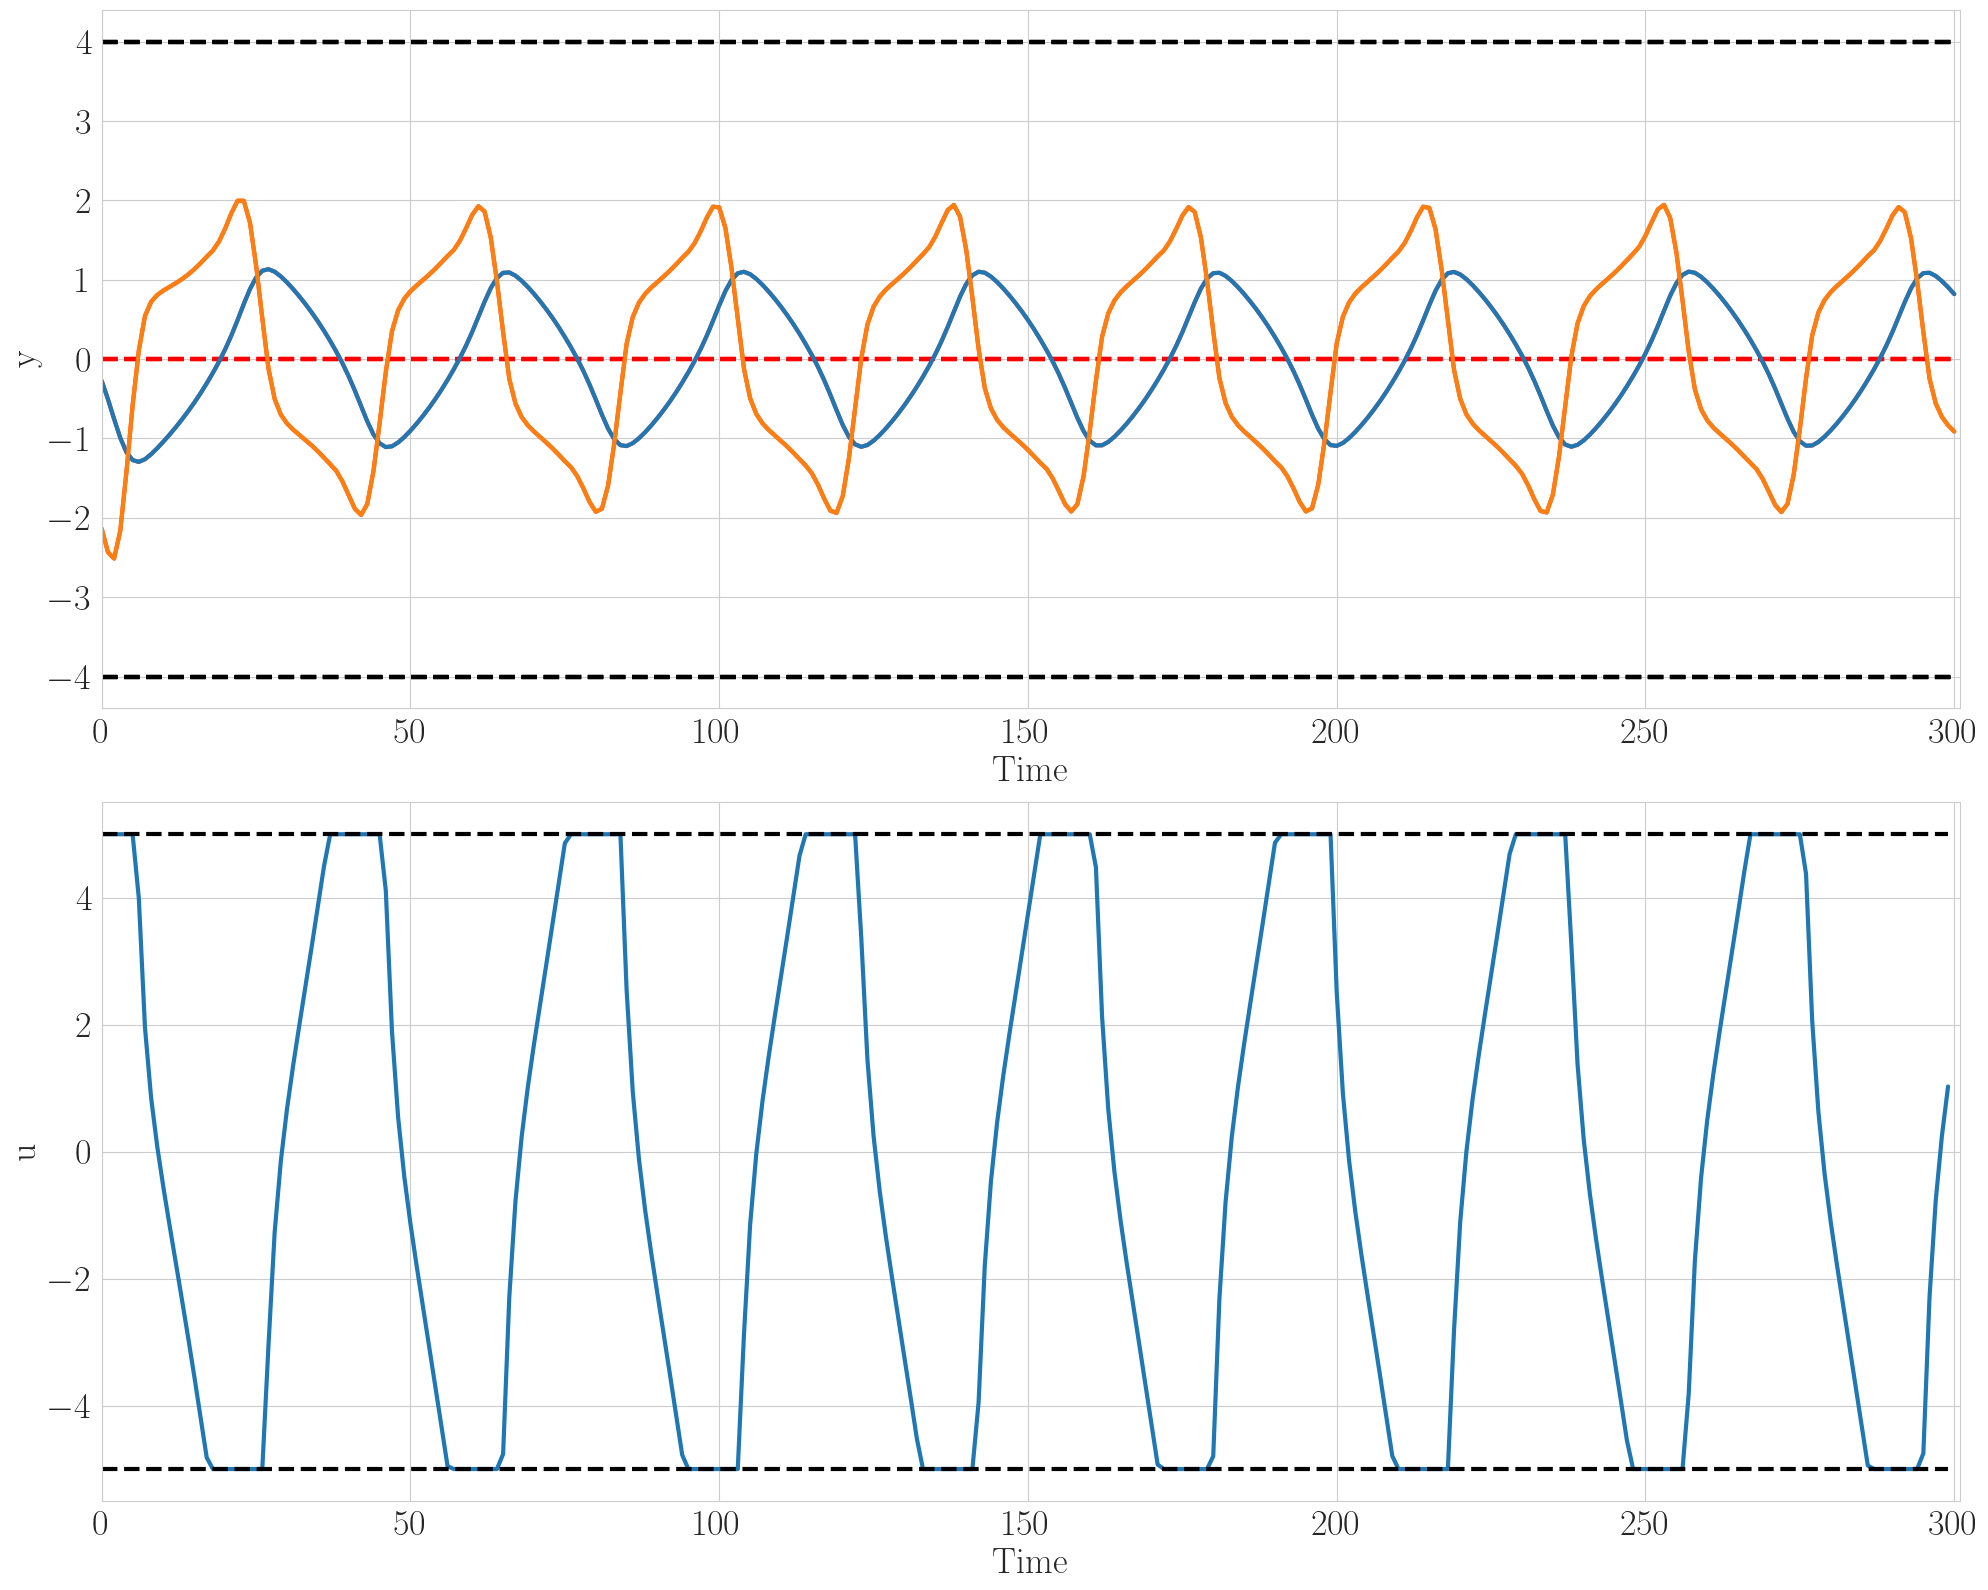

In [107]:
nsteps = 300
seed = 12
torch.manual_seed(seed)
rng = np.random.default_rng(seed)
xmin = -4.
xmax = 4.
# generate reference
torch_ref = torch.zeros(1, nsteps+1, nx, dtype=torch.float32, device=device)
data = {'xn': torch.rand(1, 1, nx, dtype=torch.float32) * (xmax-xmin) + xmin,
        'r': torch_ref}

gt_sindy_policy_noisy.nsteps = nsteps
# perform closed-loop simulation
trajectories_before_adaptation = gt_sindy_policy_noisy(data)

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])
# plot closed loop trajectories
pltCL(Y=trajectories_before_adaptation['xn'].detach().reshape(nsteps + 1, nx),
      R=trajectories_before_adaptation['r'].detach().reshape(nsteps + 1, nref),
      U=trajectories_before_adaptation['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)

#### Training Loop

In [108]:
import random

In [109]:
x_trajectory = data['xn'].detach()[:, 0, :].unsqueeze(1)
u_trajectory = torch.zeros([1,1,nu])
gamma = 1.
error_hist = []

In [110]:
# Build lists for dynamics and policies (extend these if you have >2)

for t in range(1, len(data['r'][0])):
    gt_sindy_policy_noisy.nsteps = 1
    next_step_data = gt_sindy_policy_noisy({
        'xn': x_trajectory[:, -1, :].unsqueeze(0),
        'r' : data['r'][:, len(x_trajectory[0]), :].unsqueeze(0)
    })

    x = next_step_data['xn'][:, -1, :].detach()
    r = next_step_data['r'][:,  -1, :].detach()

    policy_grads = compute_updates(
        f_funcs=fx_models,
        policies=copy_SD_SINDy_policies,
        x=x, ref=r,
        umin=umin, umax=umax
    )

    # Apply the updates
    update_policies(copy_SD_SINDy_policies, policy_grads, gamma)

    # Log trajectories
    x_trajectory = torch.cat([x_trajectory, next_step_data['xn'].detach()[:, -1:, :]], dim=1)
    u_trajectory = torch.cat([u_trajectory, next_step_data['u'].detach()[:,  -1:, :]], dim=1)

    # Track error (no hard-coded state size)
    error_hist.append((r - x).detach().cpu().numpy().ravel())

# Pack results
results = {
    "xn": x_trajectory,
    "u" : u_trajectory,
}


In [111]:

import re

def convert_to_latex_policy(names):
    """
    Correctly shifts:
    - x_0 -> x_1
    - x_1 -> x_2
    - r_0 -> r
    and applies LaTeX formatting for all terms,
    including inside composite expressions.
    """
    latex_names = []

    for name in names:
        # Step 1: Safely handle r_0 first
        name = re.sub(r'r_0', r'r', name)

        # Step 2: Temporary tags to avoid double-replacement
        name = name.replace('x_0', 'xTEMP0')
        name = name.replace('x_1', 'xTEMP1')

        # Step 3: Now shift safely
        name = name.replace('xTEMP0', 'x_1')
        name = name.replace('xTEMP1', 'x_2')

        # Step 4: LaTeX formatting
        name = name.replace('*', r' \cdot ')  # Multiplications
        name = re.sub(r'sin\((.*?)\)', r'\\sin(\1)', name)
        name = re.sub(r'cos\((.*?)\)', r'\\cos(\1)', name)
        name = re.sub(r'\^(\d+)', r'^{\1}', name)

        # Step 5: Add LaTeX subscripts for any x_N (after shift)
        name = re.sub(r'(?<![a-zA-Z])x_(\d+)', r'x_{\1}', name)

        latex_names.append(rf"${name}$")

    return latex_names
from matplotlib.ticker import FuncFormatter

# A function to plot before and after updates
# expects a function `convert_to_latex_policy(names)` in scope

def combined_controller_and_two_policy_heatmaps(
    Y_list, U_list,
    controller_labels,
    fx_policy_SINDy, fx_policy_WB,
    fx_policy_labels,
    R=None,
    style_map=None,
    TS_FIG_WIDTH=4, TS_FIG_HEIGHT=2,
    CELL_SIZE=0.3,
    FONT_SIZE_COEFS=5,
    FONT_SIZE_COEFS_LABELS=8,
    save_name="CombinedPlot.pdf",
    title=None,
    xmin=None, xmax=None,
    umin=None, umax=None,
    ACTIVE_TOL=1e-8, VMIN=-6, VMAX=6
):
    # ---------- helpers ----------
    def _names_attr(lib):
        if hasattr(lib, 'function_names'): return 'function_names'
        if hasattr(lib, 'functions_names'): return 'functions_names'
        raise AttributeError("Library needs function_names/functions_names")
    def _get_names(m): return getattr(m.library, _names_attr(m.library))
    def _coef1xN(t):
        a = t.detach().cpu().numpy()
        if a.ndim == 2: a = a[:, 0]
        return a.reshape(1, -1)
    def _ordered_union(pols):
        seen, out = set(), []
        for p in pols:
            for n in _get_names(p):
                if n not in seen: seen.add(n); out.append(n)
        return out
    def _aligned_row(p, union):
        names = _get_names(p); idx = {n:i for i,n in enumerate(names)}
        row = np.zeros((1, len(union)))
        c = _coef1xN(p.coef)
        for j,n in enumerate(union):
            i = idx.get(n)
            if i is not None: row[0, j] = c[0, i]
        return row

    # --- helpers: bold borders ---
    def _bold_spines(ax, lw=0.5, color="black"):
        for side in ("left","right","top","bottom"):
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(lw)
            ax.spines[side].set_edgecolor(color)

    def _latex_text(s: str) -> str:
        """Wrap plain text in LaTeX math mode with \\text{...}, preserving spaces."""
        if "$" in s:       # already LaTeX, don't double-wrap
            return s
        # escape LaTeX specials
        for k, v in {
            "\\": r"\textbackslash{}",
            "{": r"\{", "}": r"\}",
            "#": r"\#", "$": r"\$", "%": r"\%",
            "&": r"\&", "_": r"\_", "^": r"\^{}", "~": r"\~{}",
        }.items():
            s = s.replace(k, v)
        return rf"$\text{{{s}}}$"
        # put this near the top (you already set usetex=True)

    sns.set_style("whitegrid")
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "text.latex.preamble": r"\usepackage{amsmath}",   # needed for \text
    })


    # ---------- align + active mask (shared x-ticks) ----------
    union = _ordered_union(list(fx_policy_SINDy) + list(fx_policy_WB))
    coef_S_full = np.vstack([_aligned_row(fx, union) for fx in fx_policy_SINDy])
    coef_W_full = np.vstack([_aligned_row(fx, union) for fx in fx_policy_WB])

    active = (np.abs(coef_S_full).max(0) > ACTIVE_TOL) | (np.abs(coef_W_full).max(0) > ACTIVE_TOL)
    if not active.any():
        active[np.argmax(np.abs(np.r_[coef_S_full, coef_W_full]).max(0))] = True

    coef_S, coef_W = coef_S_full[:, active], coef_W_full[:, active]
    function_names_latex = [n for n,k in zip(convert_to_latex_policy(union), active) if k]
    n_terms = len(function_names_latex)

    # ---------- sizing ----------
    heatmap_width = n_terms * CELL_SIZE
    heatmap_height = 0.8
    gap_between_heatmaps = 0.01
    gap_between_blocks   = 0.01

    fig_height = TS_FIG_HEIGHT + 2*heatmap_height + gap_between_heatmaps + gap_between_blocks
    fig = plt.figure(figsize=(TS_FIG_WIDTH, fig_height))

    # ---------- time series (unchanged layout) ----------
    nsteps = Y_list[0].shape[0] - 1
    time = np.arange(nsteps + 1)

    top_margin = 0.62
    plot_height = 0.2
    plot_width = 0.8
    left_margin = (1 - plot_width) / 2
    heatmap_width_figunits = heatmap_width / TS_FIG_WIDTH

    plot_width = 0.38
    ax1 = fig.add_axes([left_margin, top_margin, plot_width, plot_height])
    gap_between_ts_plots = 0.07
    ax2 = fig.add_axes([left_margin + plot_width + gap_between_ts_plots, top_margin, plot_width, plot_height])

    legend_ax = fig.add_axes([left_margin, top_margin + plot_height + 0.001, 2*plot_width + 0.04, 0.05])
    legend_ax.axis("off")

    legend_handles = []
    if R is not None:
        h_ref, = ax1.plot(time, R[:, 0], '--', linewidth=0.7, color='red', label=r"$\mathrm{Ref}$")
        legend_handles.append(h_ref)

    for i in range(len(Y_list)):
        label = controller_labels[i]
        cfg = style_map[label]

        # Accept dict or tuple:
        if isinstance(cfg, dict):
            linestyle = cfg.get("linestyle", "-")
            linewidth = cfg.get("linewidth", 1.5)
            alpha     = cfg.get("alpha", 1.0)
            color     = cfg.get("color", plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10])
        else:
            # tuple formats: (linestyle, linewidth, alpha, color?) or (linestyle, linewidth, alpha)
            if len(cfg) >= 4:
                linestyle, linewidth, alpha, color = cfg[:4]
            else:
                linestyle, linewidth, alpha = cfg[:3]
                color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10]

        # plot with the color from style_map
        ax1.plot(time, Y_list[i][:, 0], linestyle=linestyle, linewidth=linewidth, alpha=alpha, color=color)
        ax1.plot(time, Y_list[i][:, 1], linestyle="--", linewidth=linewidth, alpha=alpha, color=color)

        for k in range(U_list[i].shape[1]):
            ax2.plot(time[:-1], U_list[i][:, k], linestyle=linestyle, linewidth=linewidth, alpha=alpha, color=color)

        legend_handles.append(Line2D(
            [0], [0],
            color=color, linewidth=1.3, linestyle=linestyle,
            label=_latex_text(label)
        ))

    legend_ax.legend(
        legend_handles, [h.get_label() for h in legend_handles],
        loc='center', ncol=len(legend_handles), fontsize=12,
        frameon=False, handlelength=2.5, columnspacing=1.5
    )

    #if xmin is not None: ax1.hlines(xmin, 0, nsteps, colors='black', linewidth=0.4, linestyle='--')
    #if xmax is not None: ax1.hlines(xmax, 0, nsteps, colors='black', linewidth=0.4, linestyle='--')
    if umin is not None: ax2.hlines(umin, 0, nsteps, colors='black', linewidth=0.4, linestyle='--')
    if umax is not None: ax2.hlines(umax, 0, nsteps, colors='black', linewidth=0.4, linestyle='--')
    ax1.set_ylabel(r"$x$", fontsize=15, rotation=0, labelpad=16); ax1.set_xlabel(r"$t$", fontsize=15, labelpad=8)
    ax2.set_ylabel(r"$u$", fontsize=15, rotation=0, labelpad=16); ax2.set_xlabel(r"$t$", fontsize=15, labelpad=8)
    ax1.set_xlim([0, nsteps]); ax2.set_xlim([0, nsteps])
    ax1.set_ylim([xmin, xmax])
    ax1.tick_params(axis='both', labelsize=10); ax2.tick_params(axis='both', labelsize=10)
    ax1.yaxis.set_major_locator(ticker.MultipleLocator(1.))
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(2.5))
    ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

    _bold_spines(ax1, lw=0.8)
    _bold_spines(ax2, lw=0.8)
    # ---------- heatmaps directly under TS (side-by-side, aligned to TS) ----------
    hm_w = heatmap_width / TS_FIG_WIDTH
    hm_h = heatmap_height / fig_height

    V_GAP = 0.05        # vertical gap under TS row (figure units)
    BOTTOM_SHIFT = 0.02 # extra downward shift (figure units)
    SHRINK_GAP_FRAC = 0.1  # 0..1 pull the two heatmaps toward each other

    bbox1 = ax1.get_position()
    bbox2 = ax2.get_position()
    c1 = bbox1.x0 + bbox1.width / 2.0
    c2 = bbox2.x0 + bbox2.width / 2.0
    hm_bottom = min(bbox1.y0, bbox2.y0) - V_GAP - hm_h - BOTTOM_SHIFT
    gap_current = (c2 - c1) - hm_w
    pull = max(0.0, SHRINK_GAP_FRAC * gap_current / 2.0)

    ax3_left = c1 - hm_w/2.0 + pull
    ax4_left = c2 - hm_w/2.0 - pull
    ax3 = fig.add_axes([ax3_left, hm_bottom, hm_w, hm_h])  # left heatmap (SINDy)
    ax4 = fig.add_axes([ax4_left, hm_bottom, hm_w, hm_h])  # right heatmap (WB)

    # ---------- heatmaps (rectangular cells + LaTeX annotations) ----------
    DECIMALS = 3
    CELL_ASPECT = 0.6
    CELL_BORDER = 0.5
    LABEL_PAD = 30

    sns_plots = []
    for coef, ax, label in [(coef_S, ax3, r"$\mathrm{Before}$"),
                            (coef_W, ax4, r"$\mathrm{After}$")]:
        annot_str = np.array([[rf"${v:.{DECIMALS}f}$" for v in row] for row in coef])
        hm = sns.heatmap(
            coef,
            annot=annot_str, fmt="",
            cmap="RdBu_r", center=0, vmin=VMIN, vmax=VMAX,
            square=False, linewidths=CELL_BORDER, linecolor='black',
            xticklabels=function_names_latex, yticklabels=fx_policy_labels,
            cbar=False, annot_kws={"size": FONT_SIZE_COEFS}, ax=ax
        )
        sns_plots.append(hm)
        ax.set_aspect(CELL_ASPECT)
        ax.tick_params(axis='x', rotation=90, labelsize=FONT_SIZE_COEFS_LABELS, pad=1)
        ax.tick_params(axis='y', rotation=0,  labelsize=FONT_SIZE_COEFS_LABELS, pad=5)
        ax.add_patch(patches.Rectangle((0,0), coef.shape[1], coef.shape[0],
                                       fill=False, ec='black', lw=0.75, zorder=10, clip_on=False))
        ax.annotate(label, xy=(0, 0.5), xycoords='axes fraction',
                    xytext=(-LABEL_PAD, 0), textcoords='offset points',
                    ha='right', va='center', fontsize=12, annotation_clip=False)

    # shared colorbar (to the right of the right heatmap) with LaTeX ticks
    posR = ax4.get_position()
    cbar_ax = fig.add_axes([posR.x1 + 0.01, posR.y0, 0.015, posR.height])
    cbar = plt.colorbar(sns_plots[0].collections[0], cax=cbar_ax)
    cbar.ax.tick_params(labelsize=6)
    cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: rf"${v:.{DECIMALS}f}$"))
    cbar.update_ticks()

    if title: fig.suptitle(title, fontsize=14, fontweight='bold', y=0.99)
    if save_name:
        file_format = save_name.split('.')[-1]
        fig.savefig(save_name, format=file_format, bbox_inches="tight")
    plt.show()


#### Get MPC results on the new system

In [112]:
mpc_trajectories = vdp_mpc_solve(data=data ,vdp_system=gt_model, N=50, nsim=nsteps, Rdu=0.01)

In [113]:
Y_list = [
    trajectories_before_adaptation['xn'].detach().cpu().reshape(nsteps + 1, nx),
    x_trajectory.detach().cpu().reshape(nsteps + 1, nx),
    mpc_trajectories['xn'].detach().cpu().reshape(nsteps + 1, nx)
]


U_list = [
    trajectories_before_adaptation['u'].detach().cpu().reshape(nsteps, nu),
    u_trajectory[:,:-1,:].reshape(nsteps, nu),
    mpc_trajectories['u'].detach().cpu().reshape(nsteps, nu)
]

R = trajectories_before_adaptation['r'].detach().cpu()[:,:nsteps+1].reshape(nsteps + 1, nref)

# Constraints
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Ymin = xmin * np.ones([nsteps + 1, nx])
Ymax = xmax * np.ones([nsteps + 1, nx])




In [114]:
controller_labels = ["Before Adaptation", "Online Adaptation", "MPC"]
style_map = {
    "Before Adaptation": ("-", 1.1, 0.5, "darkorange"),
    "Online Adaptation": ("-", 1.1, 0.6, "royalblue"),
    "MPC": ("-", 1.1, 0.5, "darkgreen")
}

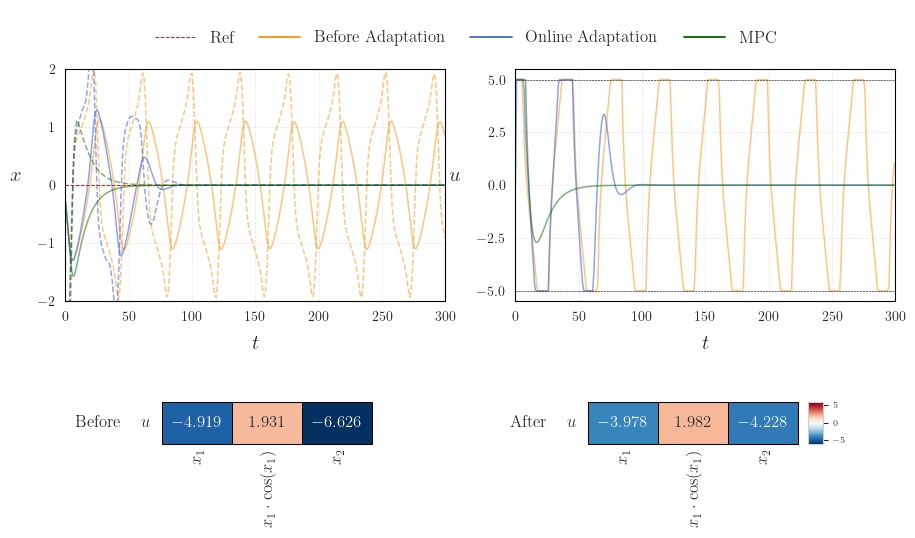

In [115]:
combined_controller_and_two_policy_heatmaps(
    Y_list=Y_list,
    U_list=U_list,
    controller_labels=controller_labels,
    fx_policy_SINDy=copy_SD_SINDy_policies,
    fx_policy_WB=SD_SINDy_policies,
    fx_policy_labels=[r"${u}$"],
    R=R,
    style_map=style_map,
    TS_FIG_WIDTH=10,
    TS_FIG_HEIGHT=10,
    CELL_SIZE=0.7,
    FONT_SIZE_COEFS=12,
    FONT_SIZE_COEFS_LABELS=12,
    xmin=-2.0, xmax=2.0,
    umin=-5.0, umax=5.0,
    title=None,
    save_name="results/VanDerPol_Adaptation.pdf"
)